[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/langchain-ai/langchain-academy/blob/main/module-4/research-assistant.ipynb) [![Open in LangChain Academy](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e9eba12c7b7688aa3dbb5e_LCA-badge-green.svg)](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58239974-lesson-4-research-assistant)

# Research Assistant

## Review

We've covered a few major LangGraph themes:

* Memory
* Human-in-the-loop
* Controllability

Now, we'll bring these ideas together to tackle one of AI's most popular applications: research automation. 

Research is often laborious work offloaded to analysts. AI has considerable potential to assist with this.

However, research demands customization: raw LLM outputs are often poorly suited for real-world decision-making workflows. 

Customized, AI-based [research and report generation](https://jxnl.co/writing/2024/06/05/predictions-for-the-future-of-rag/#reports-over-rag) workflows are a promising way to address this.

## Goal

Our goal is to build a lightweight, multi-agent system around chat models that customizes the research process.

`Source Selection` 
* Users can choose any set of input sources for their research.
  
`Planning` 
* Users provide a topic, and the system generates a team of AI analysts, each focusing on one sub-topic.
* `Human-in-the-loop` will be used to refine these sub-topics before research begins.
  
`LLM Utilization`
* Each analyst will conduct in-depth interviews with an expert AI using the selected sources.
* The interview will be a multi-turn conversation to extract detailed insights as shown in the [STORM](https://arxiv.org/abs/2402.14207) paper.
* These interviews will be captured in a using `sub-graphs` with their internal state. 
   
`Research Process`
* Experts will gather information to answer analyst questions in `parallel`.
* And all interviews will be conducted simultaneously through `map-reduce`.

`Output Format` 
* The gathered insights from each interview will be synthesized into a final report.
* We'll use customizable prompts for the report, allowing for a flexible output format. 

![Screenshot 2024-08-26 at 7.26.33 PM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbb164d61c93d48e604091_research-assistant1.png)

## Setup

In [1]:
import os
from dotenv import load_dotenv

# Expand the tilde (~) to the full /home/user path
env_path = os.path.expanduser("~/.langchain.env")

# Load the file using the absolute path
load_dotenv(dotenv_path=env_path)

# Now you can access it like a normal environment variable
openai_api_key = os.getenv("OPENAI_API_KEY")
print(f"Current Working Directory: {os.getcwd()}")
print(f"Files in directory: {os.listdir('.')}")
if not openai_api_key:
    raise ValueError("OPENAI_API_KEY not found. Check your .env file!")

print("API Key loaded successfully.")

Current Working Directory: /home/mario-useche/workspace/repos/others/langchain-academy/module-4
Files in directory: ['sub-graph.ipynb', 'map-reduce.ipynb', 'research-assistant.ipynb', 'studio', 'parallelization.ipynb']
API Key loaded successfully.


In [2]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o", temperature=0.5) 

We'll use [LangSmith](https://docs.langchain.com/langsmith/home) for [tracing](https://docs.langchain.com/langsmith/observability-concepts).

In [3]:

os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "langchain-academy"

## Generate Analysts: Human-In-The-Loop

Create analysts and review them using human-in-the-loop.

In [4]:
from typing import List
from typing_extensions import TypedDict
from pydantic import BaseModel, Field

class Analyst(BaseModel):
    affiliation: str = Field(
        description="Primary affiliation of the analyst.",
    )
    name: str = Field(
        description="Name of the analyst."
    )
    role: str = Field(
        description="Role of the analyst in the context of the topic.",
    )
    description: str = Field(
        description="Description of the analyst focus, concerns, and motives.",
    )
    @property
    def persona(self) -> str:
        return f"Name: {self.name}\nRole: {self.role}\nAffiliation: {self.affiliation}\nDescription: {self.description}\n"

class Perspectives(BaseModel):
    analysts: List[Analyst] = Field(
        description="Comprehensive list of analysts with their roles and affiliations.",
    )

class GenerateAnalystsState(TypedDict):
    topic: str # Research topic
    max_analysts: int # Number of analysts
    human_analyst_feedback: str # Human feedback
    analysts: List[Analyst] # Analyst asking questions

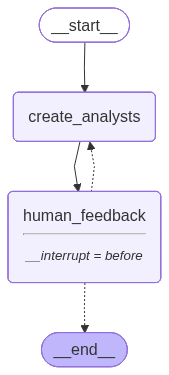

In [5]:
from IPython.display import Image, display
from langgraph.graph import START, END, StateGraph
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

analyst_instructions="""You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:

1. First, review the research topic:
{topic}
        
2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: 
        
{human_analyst_feedback}
    
3. Determine the most interesting themes based upon documents and / or feedback above.
                    
4. Pick the top {max_analysts} themes.

5. Assign one analyst to each theme."""

def create_analysts(state: GenerateAnalystsState):
    
    """ Create analysts """
    
    topic=state['topic']
    max_analysts=state['max_analysts']
    human_analyst_feedback=state.get('human_analyst_feedback', '')
        
    # Enforce structured output
    structured_llm = llm.with_structured_output(Perspectives)

    # System message
    system_message = analyst_instructions.format(topic=topic,
                                                            human_analyst_feedback=human_analyst_feedback, 
                                                            max_analysts=max_analysts)

    # Generate question 
    analysts = structured_llm.invoke([SystemMessage(content=system_message)]+[HumanMessage(content="Generate the set of analysts.")])
    
    # Write the list of analysis to state
    return {"analysts": analysts.analysts}

def human_feedback(state: GenerateAnalystsState):
    """ No-op node that should be interrupted on """
    pass

def should_continue(state: GenerateAnalystsState):
    """ Return the next node to execute """

    # Check if human feedback
    human_analyst_feedback=state.get('human_analyst_feedback', None)
    if human_analyst_feedback:
        return "create_analysts"
    
    # Otherwise end
    return END

# Add nodes and edges 
builder = StateGraph(GenerateAnalystsState)
builder.add_node("create_analysts", create_analysts)
builder.add_node("human_feedback", human_feedback)
builder.add_edge(START, "create_analysts")
builder.add_edge("create_analysts", "human_feedback")
builder.add_conditional_edges("human_feedback", should_continue, ["create_analysts", END])

# Compile
memory = MemorySaver()
graph = builder.compile(interrupt_before=['human_feedback'], checkpointer=memory)

# View
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [6]:
# Input
max_analysts = 3 
topic = "The benefits of adopting LangGraph as an agent framework"
thread = {"configurable": {"thread_id": "1"}}

# Run the graph until the first interruption
for event in graph.stream({"topic":topic,"max_analysts":max_analysts,}, thread, stream_mode="values"):
    # Review
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)  

Name: Dr. Emily Carter
Affiliation: Tech Innovations Journal
Role: Technology Analyst
Description: Dr. Carter focuses on emerging technologies and their integration into existing systems. She is particularly interested in how LangGraph can streamline agent-based frameworks to enhance efficiency and scalability in software development.
--------------------------------------------------
Name: Mr. John Chen
Affiliation: Business Strategy Insights
Role: Business Analyst
Description: Mr. Chen evaluates the economic impact and strategic advantages of adopting new technologies. His focus is on how LangGraph can provide a competitive edge to businesses by reducing operational costs and fostering innovation.
--------------------------------------------------
Name: Ms. Priya Singh
Affiliation: AI Ethics Consortium
Role: Ethics Analyst
Description: Ms. Singh examines the ethical implications of AI technologies. She is concerned with how LangGraph ensures ethical AI practices, focusing on transpar

/home/mario-useche/workspace/repos/others/langchain-academy/lc-academy-env/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Perspectives(analysts=[An...in agent frameworks.')]), input_type=Perspectives])
  return self.__pydantic_serializer__.to_python(


In [7]:
# Get state and look at next node
state = graph.get_state(thread)
state.next

Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]


('human_feedback',)

In [8]:
# We now update the state as if we are the human_feedback node
graph.update_state(thread, {"human_analyst_feedback": 
                            "Add in someone from a startup to add an entrepreneur perspective"}, as_node="human_feedback")

Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]


{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f129120-8f36-6b5c-8002-f4e6cf2a1e8e'}}

In [9]:
# Continue the graph execution
for event in graph.stream(None, thread, stream_mode="values"):
    # Review
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50) 

Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]


Name: Dr. Emily Carter
Affiliation: Tech Innovations Journal
Role: Technology Analyst
Description: Dr. Carter focuses on emerging technologies and their integration into existing systems. She is particularly interested in how LangGraph can streamline agent-based frameworks to enhance efficiency and scalability in software development.
--------------------------------------------------
Name: Mr. John Chen
Affiliation: Business Strategy Insights
Role: Business Analyst
Description: Mr. Chen evaluates the economic impact and strategic advantages of adopting new technologies. His focus is on how LangGraph can provide a competitive edge to businesses by reducing operational costs and fostering innovation.
--------------------------------------------------
Name: Ms. Priya Singh
Affiliation: AI Ethics Consortium
Role: Ethics Analyst
Description: Ms. Singh examines the ethical implications of AI technologies. She is concerned with how LangGraph ensures ethical AI practices, focusing on transpar

/home/mario-useche/workspace/repos/others/langchain-academy/lc-academy-env/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Perspectives(analysts=[An...rations efficiently.')]), input_type=Perspectives])
  return self.__pydantic_serializer__.to_python(


In [10]:
# If we are satisfied, then we simply supply no feedback
further_feedack = None
graph.update_state(thread, {"human_analyst_feedback": 
                            further_feedack}, as_node="human_feedback")

Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]


{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f129120-aec7-6c90-8004-9c6a8daf2e49'}}

In [11]:
# Continue the graph execution to end
for event in graph.stream(None, thread, stream_mode="updates"):
    print("--Node--")
    node_name = next(iter(event.keys()))
    print(node_name)

Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]


In [12]:
final_state = graph.get_state(thread)
analysts = final_state.values.get('analysts')

Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]


In [13]:
final_state.next

()

In [14]:
for analyst in analysts:
    print(f"Name: {analyst.name}")
    print(f"Affiliation: {analyst.affiliation}")
    print(f"Role: {analyst.role}")
    print(f"Description: {analyst.description}")
    print("-" * 50) 

Name: Dr. Emily Carter
Affiliation: Tech Research Institute
Role: Technology Analyst
Description: Dr. Carter focuses on evaluating emerging technologies and their potential impact on the tech industry. She is interested in how LangGraph can enhance the capabilities of agent frameworks, improve efficiency, and drive innovation in AI systems.
--------------------------------------------------
Name: Michael Thompson
Affiliation: Global Enterprise Solutions
Role: Enterprise Solutions Consultant
Description: Michael specializes in advising large enterprises on integrating new technologies to enhance their business operations. He is particularly interested in understanding how LangGraph can be leveraged to optimize enterprise workflows, reduce costs, and improve decision-making processes.
--------------------------------------------------
Name: Samantha Lee
Affiliation: InnovateX Startup Incubator
Role: Entrepreneur and Startup Advisor
Description: Samantha is a seasoned entrepreneur and adv

## Conduct Interview

### Generate Question

The analyst will ask questions to the expert.

In [15]:
import operator
from typing import  Annotated
from langgraph.graph import MessagesState

class InterviewState(MessagesState):
    max_num_turns: int # Number turns of conversation
    context: Annotated[list, operator.add] # Source docs
    analyst: Analyst # Analyst asking questions
    interview: str # Interview transcript
    sections: list # Final key we duplicate in outer state for Send() API

class SearchQuery(BaseModel):
    search_query: str = Field(None, description="Search query for retrieval.")

In [16]:
question_instructions = """You are an analyst tasked with interviewing an expert to learn about a specific topic. 

Your goal is boil down to interesting and specific insights related to your topic.

1. Interesting: Insights that people will find surprising or non-obvious.
        
2. Specific: Insights that avoid generalities and include specific examples from the expert.

Here is your topic of focus and set of goals: {goals}
        
Begin by introducing yourself using a name that fits your persona, and then ask your question.

Continue to ask questions to drill down and refine your understanding of the topic.
        
When you are satisfied with your understanding, complete the interview with: "Thank you so much for your help!"

Remember to stay in character throughout your response, reflecting the persona and goals provided to you."""

def generate_question(state: InterviewState):
    """ Node to generate a question """

    # Get state
    analyst = state["analyst"]
    messages = state["messages"]

    # Generate question 
    system_message = question_instructions.format(goals=analyst.persona)
    question = llm.invoke([SystemMessage(content=system_message)]+messages)
        
    # Write messages to state
    return {"messages": [question]}

### Generate Answer: Parallelization

The expert will gather information from multiple sources in parallel to answer questions.

For example, we can use:

* Specific web sites e.g., via [`WebBaseLoader`](https://docs.langchain.com/oss/python/integrations/document_loaders/web_base)
* Indexed documents e.g., via [RAG](https://docs.langchain.com/oss/python/langchain/retrieval)
* Web search
* Wikipedia search

You can try different web search tools, like [Tavily](https://tavily.com/).

In [17]:
def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("TAVILY_API_KEY")

In [18]:
# Web search tool
from langchain_tavily import TavilySearch  # updated 1.0

tavily_search = TavilySearch(max_results=3)

In [19]:
# Wikipedia search tool
from langchain_community.document_loaders import WikipediaLoader

Now, we create nodes to search the web and wikipedia.

We'll also create a node to answer analyst questions.

Finally, we'll create nodes to save the full interview and to write a summary ("section") of the interview.

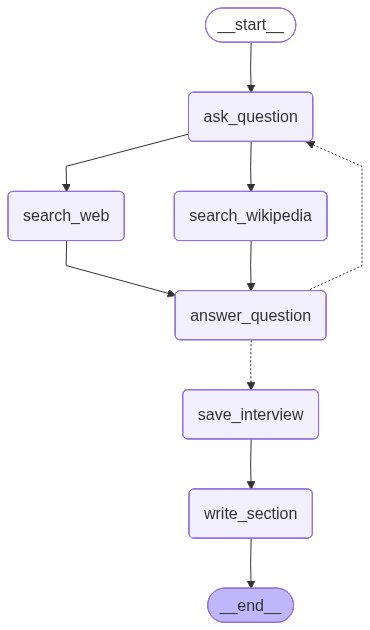

In [20]:
from langchain_core.messages import get_buffer_string

# Search query writing
search_instructions = SystemMessage(content=f"""You will be given a conversation between an analyst and an expert. 

Your goal is to generate a well-structured query for use in retrieval and / or web-search related to the conversation.
        
First, analyze the full conversation.

Pay particular attention to the final question posed by the analyst.

Convert this final question into a well-structured web search query""")

def search_web(state: InterviewState):
    
    """ Retrieve docs from web search """

    # Search query
    structured_llm = llm.with_structured_output(SearchQuery)
    search_query = structured_llm.invoke([search_instructions]+state['messages'])
    
    # Search
    #search_docs = tavily_search.invoke(search_query.search_query) # updated 1.0
    data = tavily_search.invoke({"query": search_query.search_query})
    search_docs = data.get("results", data)
    

     # Format
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document href="{doc["url"]}"/>\n{doc["content"]}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]} 

def search_wikipedia(state: InterviewState):
    
    """ Retrieve docs from wikipedia """

    # Search query
    structured_llm = llm.with_structured_output(SearchQuery)
    search_query = structured_llm.invoke([search_instructions]+state['messages'])
    
    # Search
    search_docs = WikipediaLoader(query=search_query.search_query, 
                                  load_max_docs=2).load()

     # Format
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document source="{doc.metadata["source"]}" page="{doc.metadata.get("page", "")}"/>\n{doc.page_content}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]} 

answer_instructions = """You are an expert being interviewed by an analyst.

Here is analyst area of focus: {goals}. 
        
You goal is to answer a question posed by the interviewer.

To answer question, use this context:
        
{context}

When answering questions, follow these guidelines:
        
1. Use only the information provided in the context. 
        
2. Do not introduce external information or make assumptions beyond what is explicitly stated in the context.

3. The context contain sources at the topic of each individual document.

4. Include these sources your answer next to any relevant statements. For example, for source # 1 use [1]. 

5. List your sources in order at the bottom of your answer. [1] Source 1, [2] Source 2, etc
        
6. If the source is: <Document source="assistant/docs/llama3_1.pdf" page="7"/>' then just list: 
        
[1] assistant/docs/llama3_1.pdf, page 7 
        
And skip the addition of the brackets as well as the Document source preamble in your citation."""

def generate_answer(state: InterviewState):
    
    """ Node to answer a question """

    # Get state
    analyst = state["analyst"]
    messages = state["messages"]
    context = state["context"]

    # Answer question
    system_message = answer_instructions.format(goals=analyst.persona, context=context)
    answer = llm.invoke([SystemMessage(content=system_message)]+messages)
            
    # Name the message as coming from the expert
    answer.name = "expert"
    
    # Append it to state
    return {"messages": [answer]}

def save_interview(state: InterviewState):
    
    """ Save interviews """

    # Get messages
    messages = state["messages"]
    
    # Convert interview to a string
    interview = get_buffer_string(messages)
    
    # Save to interviews key
    return {"interview": interview}

def route_messages(state: InterviewState, 
                   name: str = "expert"):

    """ Route between question and answer """
    
    # Get messages
    messages = state["messages"]
    max_num_turns = state.get('max_num_turns',2)

    # Check the number of expert answers 
    num_responses = len(
        [m for m in messages if isinstance(m, AIMessage) and m.name == name]
    )

    # End if expert has answered more than the max turns
    if num_responses >= max_num_turns:
        return 'save_interview'

    # This router is run after each question - answer pair 
    # Get the last question asked to check if it signals the end of discussion
    last_question = messages[-2]
    
    if "Thank you so much for your help" in last_question.content:
        return 'save_interview'
    return "ask_question"

section_writer_instructions = """You are an expert technical writer. 
            
Your task is to create a short, easily digestible section of a report based on a set of source documents.

1. Analyze the content of the source documents: 
- The name of each source document is at the start of the document, with the <Document tag.
        
2. Create a report structure using markdown formatting:
- Use ## for the section title
- Use ### for sub-section headers
        
3. Write the report following this structure:
a. Title (## header)
b. Summary (### header)
c. Sources (### header)

4. Make your title engaging based upon the focus area of the analyst: 
{focus}

5. For the summary section:
- Set up summary with general background / context related to the focus area of the analyst
- Emphasize what is novel, interesting, or surprising about insights gathered from the interview
- Create a numbered list of source documents, as you use them
- Do not mention the names of interviewers or experts
- Aim for approximately 400 words maximum
- Use numbered sources in your report (e.g., [1], [2]) based on information from source documents
        
6. In the Sources section:
- Include all sources used in your report
- Provide full links to relevant websites or specific document paths
- Separate each source by a newline. Use two spaces at the end of each line to create a newline in Markdown.
- It will look like:

### Sources
[1] Link or Document name
[2] Link or Document name

7. Be sure to combine sources. For example this is not correct:

[3] https://ai.meta.com/blog/meta-llama-3-1/
[4] https://ai.meta.com/blog/meta-llama-3-1/

There should be no redundant sources. It should simply be:

[3] https://ai.meta.com/blog/meta-llama-3-1/
        
8. Final review:
- Ensure the report follows the required structure
- Include no preamble before the title of the report
- Check that all guidelines have been followed"""

def write_section(state: InterviewState):

    """ Node to answer a question """

    # Get state
    interview = state["interview"]
    context = state["context"]
    analyst = state["analyst"]
   
    # Write section using either the gathered source docs from interview (context) or the interview itself (interview)
    system_message = section_writer_instructions.format(focus=analyst.description)
    section = llm.invoke([SystemMessage(content=system_message)]+[HumanMessage(content=f"Use this source to write your section: {context}")]) 
                
    # Append it to state
    return {"sections": [section.content]}

# Add nodes and edges 
interview_builder = StateGraph(InterviewState)
interview_builder.add_node("ask_question", generate_question)
interview_builder.add_node("search_web", search_web)
interview_builder.add_node("search_wikipedia", search_wikipedia)
interview_builder.add_node("answer_question", generate_answer)
interview_builder.add_node("save_interview", save_interview)
interview_builder.add_node("write_section", write_section)

# Flow
interview_builder.add_edge(START, "ask_question")
interview_builder.add_edge("ask_question", "search_web")
interview_builder.add_edge("ask_question", "search_wikipedia")
interview_builder.add_edge("search_web", "answer_question")
interview_builder.add_edge("search_wikipedia", "answer_question")
interview_builder.add_conditional_edges("answer_question", route_messages,['ask_question','save_interview'])
interview_builder.add_edge("save_interview", "write_section")
interview_builder.add_edge("write_section", END)

# Interview 
memory = MemorySaver()
interview_graph = interview_builder.compile(checkpointer=memory).with_config(run_name="Conduct Interviews")

# View
display(Image(interview_graph.get_graph().draw_mermaid_png()))

In [21]:
# Pick one analyst
analysts[0]

Analyst(affiliation='Tech Research Institute', name='Dr. Emily Carter', role='Technology Analyst', description='Dr. Carter focuses on evaluating emerging technologies and their potential impact on the tech industry. She is interested in how LangGraph can enhance the capabilities of agent frameworks, improve efficiency, and drive innovation in AI systems.')

Here, we run the interview passing an index of the llama3.1 paper, which is related to our topic.

In [22]:
from IPython.display import Markdown
messages = [HumanMessage(f"So you said you were writing an article on {topic}?")]
thread = {"configurable": {"thread_id": "1"}}
interview = interview_graph.invoke({"analyst": analysts[0], "messages": messages, "max_num_turns": 2}, thread)
Markdown(interview['sections'][0])

/home/mario-useche/workspace/repos/others/langchain-academy/lc-academy-env/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=SearchQuery(search_query=... AI systems efficiency'), input_type=SearchQuery])
  return self.__pydantic_serializer__.to_python(
/home/mario-useche/workspace/repos/others/langchain-academy/lc-academy-env/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=SearchQuery(search_query=...ramework in AI systems'), input_type=SearchQuery])
  return self.__pydantic_serializer__.to_python(
/home/mario-useche/workspace/repos/others/langchain-academy/lc-academy-env/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydan

## LangGraph: Revolutionizing AI Agent Frameworks for Enhanced Efficiency and Innovation

### Summary

In the rapidly evolving landscape of artificial intelligence, the development of robust and efficient agent frameworks is crucial for handling increasingly complex tasks. LangGraph has emerged as a transformative orchestration framework designed to enhance the capabilities of AI systems. By providing a reliable orchestration layer, LangGraph allows for explicit control over context management, persistence, fault tolerance, and human-in-the-loop interactions, thus addressing key production concerns in AI deployment [1].

One of the most compelling aspects of LangGraph is its dual API approach—both declarative and imperative—which supports a series of agent abstractions. This flexibility makes it an ideal choice for developers looking to build reliable, scalable agentic systems [2]. LangGraph's event-driven nature further enhances its ability to handle complex, multi-agent workflows, making it a standout in the field of AI agent frameworks.

Moreover, LangGraph's integration with tools like Maxim AI for comprehensive tracing and monitoring provides deep insights into agent behavior. This integration not only identifies failure points but also offers a pathway to continuously improve multi-agent system performance, ensuring production-grade reliability [3]. Such capabilities are vital for maintaining context and optimizing agent performance, especially in dynamic environments where seamless integration with existing tools and APIs is required.

LangGraph also supports the creation of sophisticated multi-agent systems that can mimic developer workflows, including reading documentation, testing, refining, and learning from feedback. This structured approach, powered by state machines and graph nodes, allows for the development of intelligent AI agents capable of maintaining context and adapting to new information [4].

The innovative features of LangGraph, including its orchestration capabilities and integration with observability tools, are driving significant interest and adoption in the AI community. As AI systems continue to evolve, frameworks like LangGraph will play a pivotal role in enabling more efficient, reliable, and innovative applications.

### Sources
[1] https://blog.langchain.com/how-to-think-about-agent-frameworks/  
[2] https://medium.com/@meisshaily/how-langgraph-transforms-ai-agents-2e20b27e0fee  
[3] https://www.getmaxim.ai/articles/how-to-continuously-improve-your-langgraph-multi-agent-system/  
[4] https://www.projectpro.io/article/langgraph-projects-and-examples/1124  

### Parallelze interviews: Map-Reduce

We parallelize the interviews via the `Send()` API, a map step.

We combine them into the report body in a reduce step.

### Finalize

We add a final step to write an intro and conclusion to the final report.

In [23]:
import operator
from typing import List, Annotated
from typing_extensions import TypedDict

class ResearchGraphState(TypedDict):
    topic: str # Research topic
    max_analysts: int # Number of analysts
    human_analyst_feedback: str # Human feedback
    analysts: List[Analyst] # Analyst asking questions
    sections: Annotated[list, operator.add] # Send() API key
    introduction: str # Introduction for the final report
    content: str # Content for the final report
    conclusion: str # Conclusion for the final report
    final_report: str # Final report

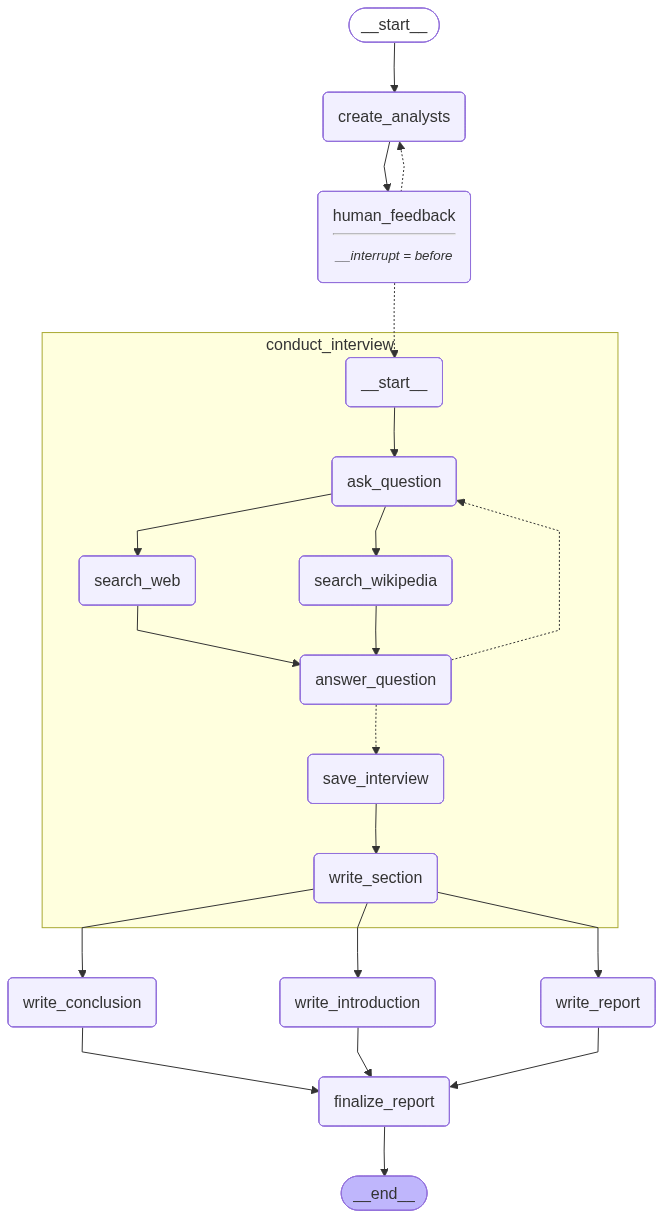

In [24]:
from langgraph.types import Send # updated in 1.0
def initiate_all_interviews(state: ResearchGraphState):
    """ This is the "map" step where we run each interview sub-graph using Send API """    

    # Check if human feedback
    human_analyst_feedback=state.get('human_analyst_feedback')
    if human_analyst_feedback:
        # Return to create_analysts
        return "create_analysts"

    # Otherwise kick off interviews in parallel via Send() API
    else:
        topic = state["topic"]
        return [Send("conduct_interview", {"analyst": analyst,
                                           "messages": [HumanMessage(
                                               content=f"So you said you were writing an article on {topic}?"
                                           )
                                                       ]}) for analyst in state["analysts"]]

report_writer_instructions = """You are a technical writer creating a report on this overall topic: 

{topic}
    
You have a team of analysts. Each analyst has done two things: 

1. They conducted an interview with an expert on a specific sub-topic.
2. They write up their finding into a memo.

Your task: 

1. You will be given a collection of memos from your analysts.
2. Think carefully about the insights from each memo.
3. Consolidate these into a crisp overall summary that ties together the central ideas from all of the memos. 
4. Summarize the central points in each memo into a cohesive single narrative.

To format your report:
 
1. Use markdown formatting. 
2. Include no pre-amble for the report.
3. Use no sub-heading. 
4. Start your report with a single title header: ## Insights
5. Do not mention any analyst names in your report.
6. Preserve any citations in the memos, which will be annotated in brackets, for example [1] or [2].
7. Create a final, consolidated list of sources and add to a Sources section with the `## Sources` header.
8. List your sources in order and do not repeat.

[1] Source 1
[2] Source 2

Here are the memos from your analysts to build your report from: 

{context}"""

def write_report(state: ResearchGraphState):
    # Full set of sections
    sections = state["sections"]
    topic = state["topic"]

    # Concat all sections together
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])
    
    # Summarize the sections into a final report
    system_message = report_writer_instructions.format(topic=topic, context=formatted_str_sections)    
    report = llm.invoke([SystemMessage(content=system_message)]+[HumanMessage(content=f"Write a report based upon these memos.")]) 
    return {"content": report.content}

intro_conclusion_instructions = """You are a technical writer finishing a report on {topic}

You will be given all of the sections of the report.

You job is to write a crisp and compelling introduction or conclusion section.

The user will instruct you whether to write the introduction or conclusion.

Include no pre-amble for either section.

Target around 100 words, crisply previewing (for introduction) or recapping (for conclusion) all of the sections of the report.

Use markdown formatting. 

For your introduction, create a compelling title and use the # header for the title.

For your introduction, use ## Introduction as the section header. 

For your conclusion, use ## Conclusion as the section header.

Here are the sections to reflect on for writing: {formatted_str_sections}"""

def write_introduction(state: ResearchGraphState):
    # Full set of sections
    sections = state["sections"]
    topic = state["topic"]

    # Concat all sections together
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])
    
    # Summarize the sections into a final report
    
    instructions = intro_conclusion_instructions.format(topic=topic, formatted_str_sections=formatted_str_sections)    
    intro = llm.invoke([instructions]+[HumanMessage(content=f"Write the report introduction")]) 
    return {"introduction": intro.content}

def write_conclusion(state: ResearchGraphState):
    # Full set of sections
    sections = state["sections"]
    topic = state["topic"]

    # Concat all sections together
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])
    
    # Summarize the sections into a final report
    
    instructions = intro_conclusion_instructions.format(topic=topic, formatted_str_sections=formatted_str_sections)    
    conclusion = llm.invoke([instructions]+[HumanMessage(content=f"Write the report conclusion")]) 
    return {"conclusion": conclusion.content}

def finalize_report(state: ResearchGraphState):
    """ The is the "reduce" step where we gather all the sections, combine them, and reflect on them to write the intro/conclusion """
    # Save full final report
    content = state["content"]
    if content.startswith("## Insights"):
        content = content.strip("## Insights")
    if "## Sources" in content:
        try:
            content, sources = content.split("\n## Sources\n")
        except:
            sources = None
    else:
        sources = None

    final_report = state["introduction"] + "\n\n---\n\n" + content + "\n\n---\n\n" + state["conclusion"]
    if sources is not None:
        final_report += "\n\n## Sources\n" + sources
    return {"final_report": final_report}

# Add nodes and edges 
builder = StateGraph(ResearchGraphState)
builder.add_node("create_analysts", create_analysts)
builder.add_node("human_feedback", human_feedback)
builder.add_node("conduct_interview", interview_builder.compile())
builder.add_node("write_report",write_report)
builder.add_node("write_introduction",write_introduction)
builder.add_node("write_conclusion",write_conclusion)
builder.add_node("finalize_report",finalize_report)

# Logic
builder.add_edge(START, "create_analysts")
builder.add_edge("create_analysts", "human_feedback")
builder.add_conditional_edges("human_feedback", initiate_all_interviews, ["create_analysts", "conduct_interview"])
builder.add_edge("conduct_interview", "write_report")
builder.add_edge("conduct_interview", "write_introduction")
builder.add_edge("conduct_interview", "write_conclusion")
builder.add_edge(["write_conclusion", "write_report", "write_introduction"], "finalize_report")
builder.add_edge("finalize_report", END)

# Compile
memory = MemorySaver()
graph = builder.compile(interrupt_before=['human_feedback'], checkpointer=memory)
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

Let's ask an open-ended question about LangGraph.

In [25]:
# Inputs
max_analysts = 1 
topic = "Why to use LangGraph as an agent framework instead of using n8n?"
thread = {"configurable": {"thread_id": "1"}}

# Run the graph until the first interruption
for event in graph.stream({"topic":topic,
                           "max_analysts":max_analysts}, 
                          thread, 
                          stream_mode="values"):
    
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)  

Name: Dr. Emily Chen
Affiliation: Tech Innovation Lab
Role: Technology Analyst
Description: Dr. Emily Chen focuses on evaluating emerging technologies and their practical applications in business environments. Her primary concern is assessing the scalability, flexibility, and integration capabilities of new frameworks like LangGraph compared to established tools such as n8n. She is motivated by the desire to identify technologies that can provide significant competitive advantages through improved efficiency and innovation.
--------------------------------------------------


/home/mario-useche/workspace/repos/others/langchain-academy/lc-academy-env/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Perspectives(analysts=[An...ency and innovation.')]), input_type=Perspectives])
  return self.__pydantic_serializer__.to_python(


In [26]:
# We now update the state as if we are the human_feedback node
graph.update_state(thread, {"human_analyst_feedback": 
                                "Add in the CEO of N8N"}, as_node="human_feedback")

Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]


{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f129121-b655-6e60-8002-079013d30531'}}

In [27]:
# Check
for event in graph.stream(None, thread, stream_mode="values"):
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)  

Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]


Name: Dr. Emily Chen
Affiliation: Tech Innovation Lab
Role: Technology Analyst
Description: Dr. Emily Chen focuses on evaluating emerging technologies and their practical applications in business environments. Her primary concern is assessing the scalability, flexibility, and integration capabilities of new frameworks like LangGraph compared to established tools such as n8n. She is motivated by the desire to identify technologies that can provide significant competitive advantages through improved efficiency and innovation.
--------------------------------------------------
Name: Dr. Emily Carter
Affiliation: LangGraph
Role: Chief Technology Officer
Description: Dr. Carter is focused on the technical superiority and innovative capabilities of LangGraph. She emphasizes the framework's flexibility, integration capabilities, and how it can handle complex workflows more efficiently compared to traditional tools like n8n.
--------------------------------------------------
Name: Jan Oberhaus

/home/mario-useche/workspace/repos/others/langchain-academy/lc-academy-env/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Perspectives(analysts=[An...technical expertise.")]), input_type=Perspectives])
  return self.__pydantic_serializer__.to_python(


In [28]:
# Confirm we are happy
graph.update_state(thread, {"human_analyst_feedback": 
                            None}, as_node="human_feedback")

Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]


{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f129121-d281-68a8-8004-f25b436f1608'}}

In [29]:
# Continue
for event in graph.stream(None, thread, stream_mode="updates"):
    print("--Node--")
    node_name = next(iter(event.keys()))
    print(node_name)

Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
/home/mario-useche/workspace/repos/others/langchain-academy/lc-academy-env/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', inpu

--Node--
conduct_interview
--Node--
conduct_interview
--Node--
write_introduction
--Node--
write_conclusion
--Node--
write_report
--Node--
finalize_report


In [30]:
from IPython.display import Markdown
final_state = graph.get_state(thread)
report = final_state.values.get('final_report')
Markdown(report)

Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]


# Choosing the Right Framework: LangGraph vs. n8n for AI Workflows

## Introduction

In the dynamic realm of AI and automation, selecting an appropriate framework is pivotal for maximizing workflow efficiency and integration. This report delves into the advantages of using LangGraph, an AI-first framework developed by LangChain, over traditional tools like n8n. LangGraph's state graph architecture excels in managing complex reasoning and context, offering high customization through pre-made agents and connectors. It seamlessly integrates hybrid workflows, enhancing AI logic management while simplifying debugging. In contrast, n8n's user-friendly interface and community-driven support make it ideal for low-code automation. This report explores how LangGraph's technical prowess provides a robust alternative for advanced AI applications.

---



In the fast-paced realm of AI and automation, selecting the appropriate framework is pivotal for maximizing workflow efficiency and integration. LangGraph, an open-source framework by LangChain, has emerged as a superior choice for AI-specific tasks due to its AI-first design, which excels in handling complex reasoning, branching, and context management. LangGraph's state graph architecture facilitates the construction and deployment of AI agent workflows, allowing for the integration of pre-made agents, tools, and connectors for databases and third-party APIs. This provides developers with significant customization and control [1][3]. Unlike n8n, a general-purpose workflow automation tool, LangGraph's specialization in AI workflows makes it more suitable for complex AI applications requiring intricate decision-making processes [1].

A notable insight is LangGraph's seamless integration with other systems, enabling the creation of hybrid workflows that leverage both AI-centric and general automation capabilities. Teams can use LangGraph for managing AI logic while utilizing n8n for handling external integrations, achieving a balanced and flexible AI stack [1]. This dual approach enhances the robustness of AI workflows and simplifies debugging and optimization by providing a clear view of execution paths across different platforms [1].

LangGraph's open-source nature and support for creating fully configurable and codable tools make it an attractive choice for developers seeking to build highly custom, stateful, and non-linear agentic workflows. This flexibility benefits enterprises engaged in collaborative, long-running, and complex multi-agent tasks [3]. The framework caters to both experienced developers and teams aiming for rapid prototyping and low-code automation, underscoring its versatility in diverse business contexts [3].

Conversely, n8n stands out for its user-friendly interface and community-driven approach. It empowers users, even those without deep technical expertise, to automate processes efficiently. With its visual workflow builder and extensive integration capabilities, n8n allows users to streamline operations and connect disparate systems. Its low-code nature enables users to construct workflows visually, making it accessible to a broader audience, including those lacking advanced coding skills. Unlike LangGraph, which caters to developers seeking fine-tuned control over agent logic, n8n provides a simpler yet powerful alternative for deploying production-ready workflows [1].

n8n's strength lies in its extensive integration capabilities, connecting over 400 business applications through visual workflows. It is particularly beneficial for businesses looking to automate processes across multiple systems. n8n can trigger LangGraph agents via HTTP requests, orchestrate multi-step processes, and integrate with tools like Slack, databases, and external APIs, making it a versatile choice for various automation needs [2].

Additionally, n8n's community-driven approach enhances its appeal. The platform benefits from robust ecosystem support, with community nodes and templates available to help users initiate automation projects. This community support, combined with comprehensive documentation, ensures users can quickly learn and optimize their workflows, regardless of their technical background [3]. n8n's pricing model is designed to be affordable and scalable, offering flexibility and cost-effectiveness, particularly for IT Ops workflows [4].

In conclusion, while LangGraph excels in handling complex AI workflows with precision and flexibility, offering a robust alternative to traditional workflow automation tools, n8n's user-friendly interface, community-driven support, and extensive integration capabilities make it a compelling choice for users seeking to automate processes without deep technical expertise. Both frameworks have their unique strengths, making them suitable for different automation needs and organizational contexts.


---

## Conclusion

In the rapidly evolving landscape of AI and automation, the choice between LangGraph and n8n hinges on specific workflow needs and technical expertise. LangGraph excels with its AI-first design, offering a robust framework for complex reasoning and context management, making it ideal for intricate AI applications. Its state graph architecture and open-source flexibility empower developers to create highly customized workflows. Conversely, n8n shines with its user-friendly interface and community-driven support, enabling users without deep technical skills to automate processes effectively. While LangGraph provides precision and control for AI-centric tasks, n8n offers accessibility and extensive integration capabilities for broader automation needs. Both tools present unique advantages, allowing organizations to tailor their automation strategies to their specific requirements.

## Sources
[1] https://www.truefoundry.com/blog/langgraph-vs-n8n  
[2] https://inkeep.com/blog/agent-frameworks-platforms-overview  
[3] https://www.3pillarglobal.com/insights/blog/comparison-crewai-langgraph-n8n  
[4] https://n8n.io/workflows/categories/it-ops/

We can look at the trace:

https://smith.langchain.com/public/2933a7bb-bcef-4d2d-9b85-cc735b22ca0c/r